# Stranger Pulses: HTRU2 Pulsar Detection
Binary Classification & Analysis
1. Background & Dataset Explanation
The HTRU2 Dataset HTRU2 is a dataset describing a sample of pulsar candidates collected during the High Time Resolution Universe Survey (South).

What is a Pulsar? Pulsars are a rare type of Neutron star that produce radio emission detectable here on Earth. They are of considerable scientific interest as probes of space-time, the interstellar medium, and states of matter.

The Problem Machine learning tools are used to automatically label pulsar candidates to facilitate rapid analysis. Classification systems in particular are widely adopted, which treat the candidate data sets as binary classification problems.

Class 0: Radio Frequency Interference (RFI) / Noise

Class 1: Real Pulsar

Feature Explanations The data contains 17,898 examples. Each candidate is described by 8 continuous variables (and a class label). The first four are simple statistics obtained from the Integrated Pulse Profile (folded profile). The remaining four are obtained from the DM-SNR Curve (Dispersion Measure - Signal to Noise Ratio).

1) Mean of the integrated profile: The average signal strength.

2) Standard deviation of the integrated profile: Variability of the signal.

3) Excess kurtosis of the integrated profile: Sharpness of the peak.

4) Skewness of the integrated profile: Asymmetry of the signal.

5) Mean of the DM-SNR curve: Average dispersion measure.

6) Standard deviation of the DM-SNR curve: Variability in dispersion.

7) Excess kurtosis of the DM-SNR curve: Sharpness of the DM curve.

8) Skewness of the DM-SNR curve: Asymmetry of the DM curve.

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
htru2 = fetch_ucirepo(id=372)
# data (as pandas dataframes)
X = htru2.data.features
y = htru2.data.targets
df = pd.concat([X, y], axis=1)
print(df)

       Profile_mean  Profile_stdev  Profile_skewness  Profile_kurtosis  \
0        140.562500      55.683782         -0.234571         -0.699648   
1        102.507812      58.882430          0.465318         -0.515088   
2        103.015625      39.341649          0.323328          1.051164   
3        136.750000      57.178449         -0.068415         -0.636238   
4         88.726562      40.672225          0.600866          1.123492   
...             ...            ...               ...               ...   
17893    136.429688      59.847421         -0.187846         -0.738123   
17894    122.554688      49.485605          0.127978          0.323061   
17895    119.335938      59.935939          0.159363         -0.743025   
17896    114.507812      53.902400          0.201161         -0.024789   
17897     57.062500      85.797340          1.406391          0.089520   

          DM_mean   DM_stdev  DM_skewness  DM_kurtosis  class  
0        3.199833  19.110426     7.975532    74

In [ ]:
# 1. Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
import requests
import zipfile

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
import warnings
warnings.filterwarnings('ignore')

# Rename columns for readability
df.columns = ['Mean_of_the_integrated_profile',
'Standard_deviation_of_the_integrated_profile',
'Skewness_of_the_integrated_profile',
'Excess_kurtosis_of_the_integrated_profile',
'Mean_of_the_DM_SNR_curve',
'Standard_deviation_of_the_DM_SNR_curve',
'Skewness_of_the_DM_SNR_curve',
'Excess_kurtosis_of_the_DM_SNR_curve',
'target_class']

# Display basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (17898, 9)


,Mean_of_the_integrated_profile,Standard_deviation_of_the_integrated_profile,Skewness_of_the_integrated_profile,Excess_kurtosis_of_the_integrated_profile,Mean_of_the_DM_SNR_curve,Standard_deviation_of_the_DM_SNR_curve,Skewness_of_the_DM_SNR_curve,Excess_kurtosis_of_the_DM_SNR_curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


2. Exploratory Data Analysis (EDA)
Here we analyze the distributions, correlations, and class imbalance of the dataset.

- Class Imbalance: We expect pulsars to be very rare compared to noise.

- Correlation: We check if the Profile features correlate with DM-SNR features.

In [ ]:
# 2.1 Missing Values Check
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Mean_of_the_integrated_profile                  0
Standard_deviation_of_the_integrated_profile    0
Skewness_of_the_integrated_profile              0
Excess_kurtosis_of_the_integrated_profile       0
Mean_of_the_DM_SNR_curve                        0
Standard_deviation_of_the_DM_SNR_curve          0
Skewness_of_the_DM_SNR_curve                    0
Excess_kurtosis_of_the_DM_SNR_curve             0
target_class                                    0
dtype: int64


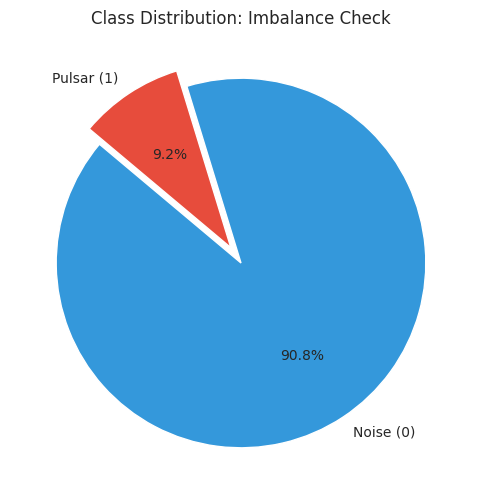

In [ ]:
# 2.2 Class Imbalance Pie Chart
plt.figure(figsize=(6, 6))
class_counts = df['target_class'].value_counts()
plt.pie(class_counts, labels=['Noise (0)', 'Pulsar (1)'], autopct='%1.1f%%',
        colors=['#3498db', '#e74c3c'], startangle=140, explode=(0, 0.1))
plt.title('Class Distribution: Imbalance Check')
plt.show()

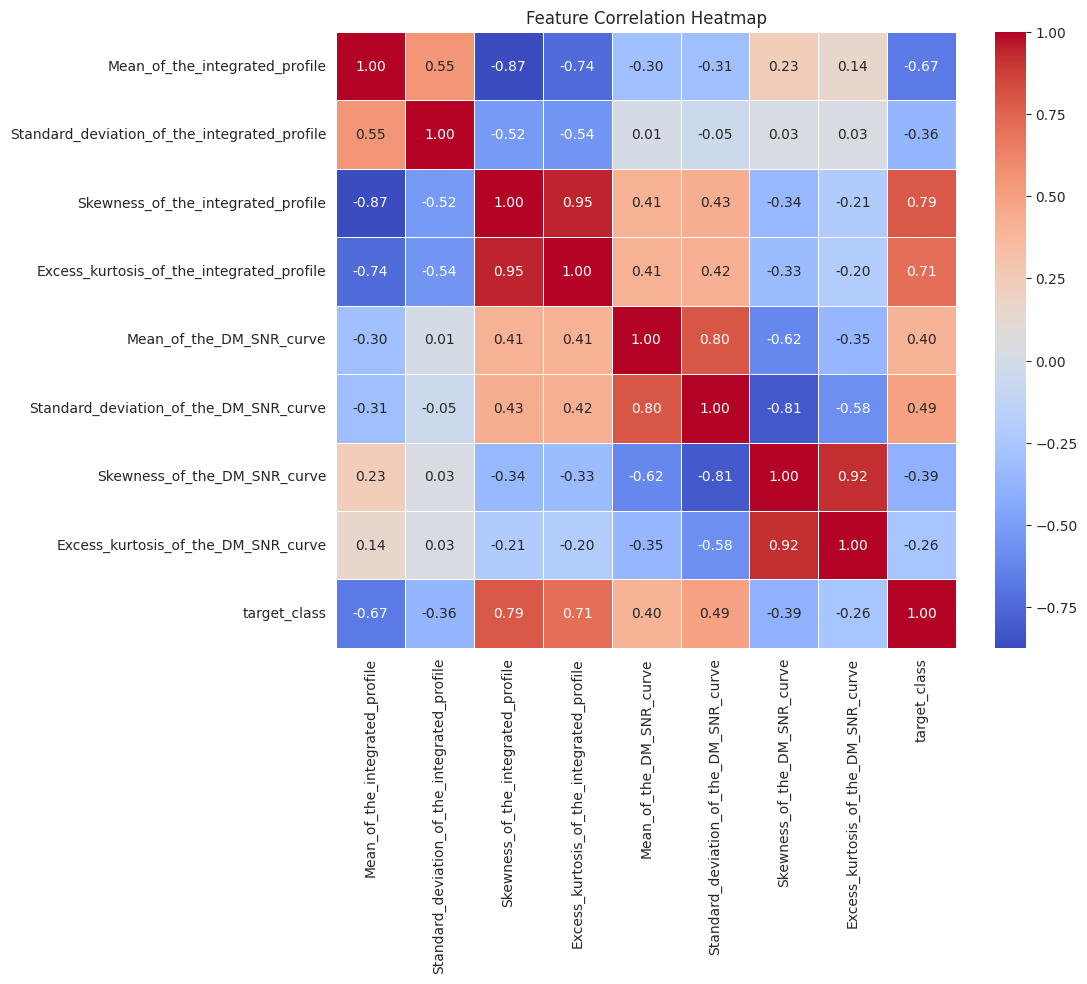

In [ ]:
# 2.3 Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


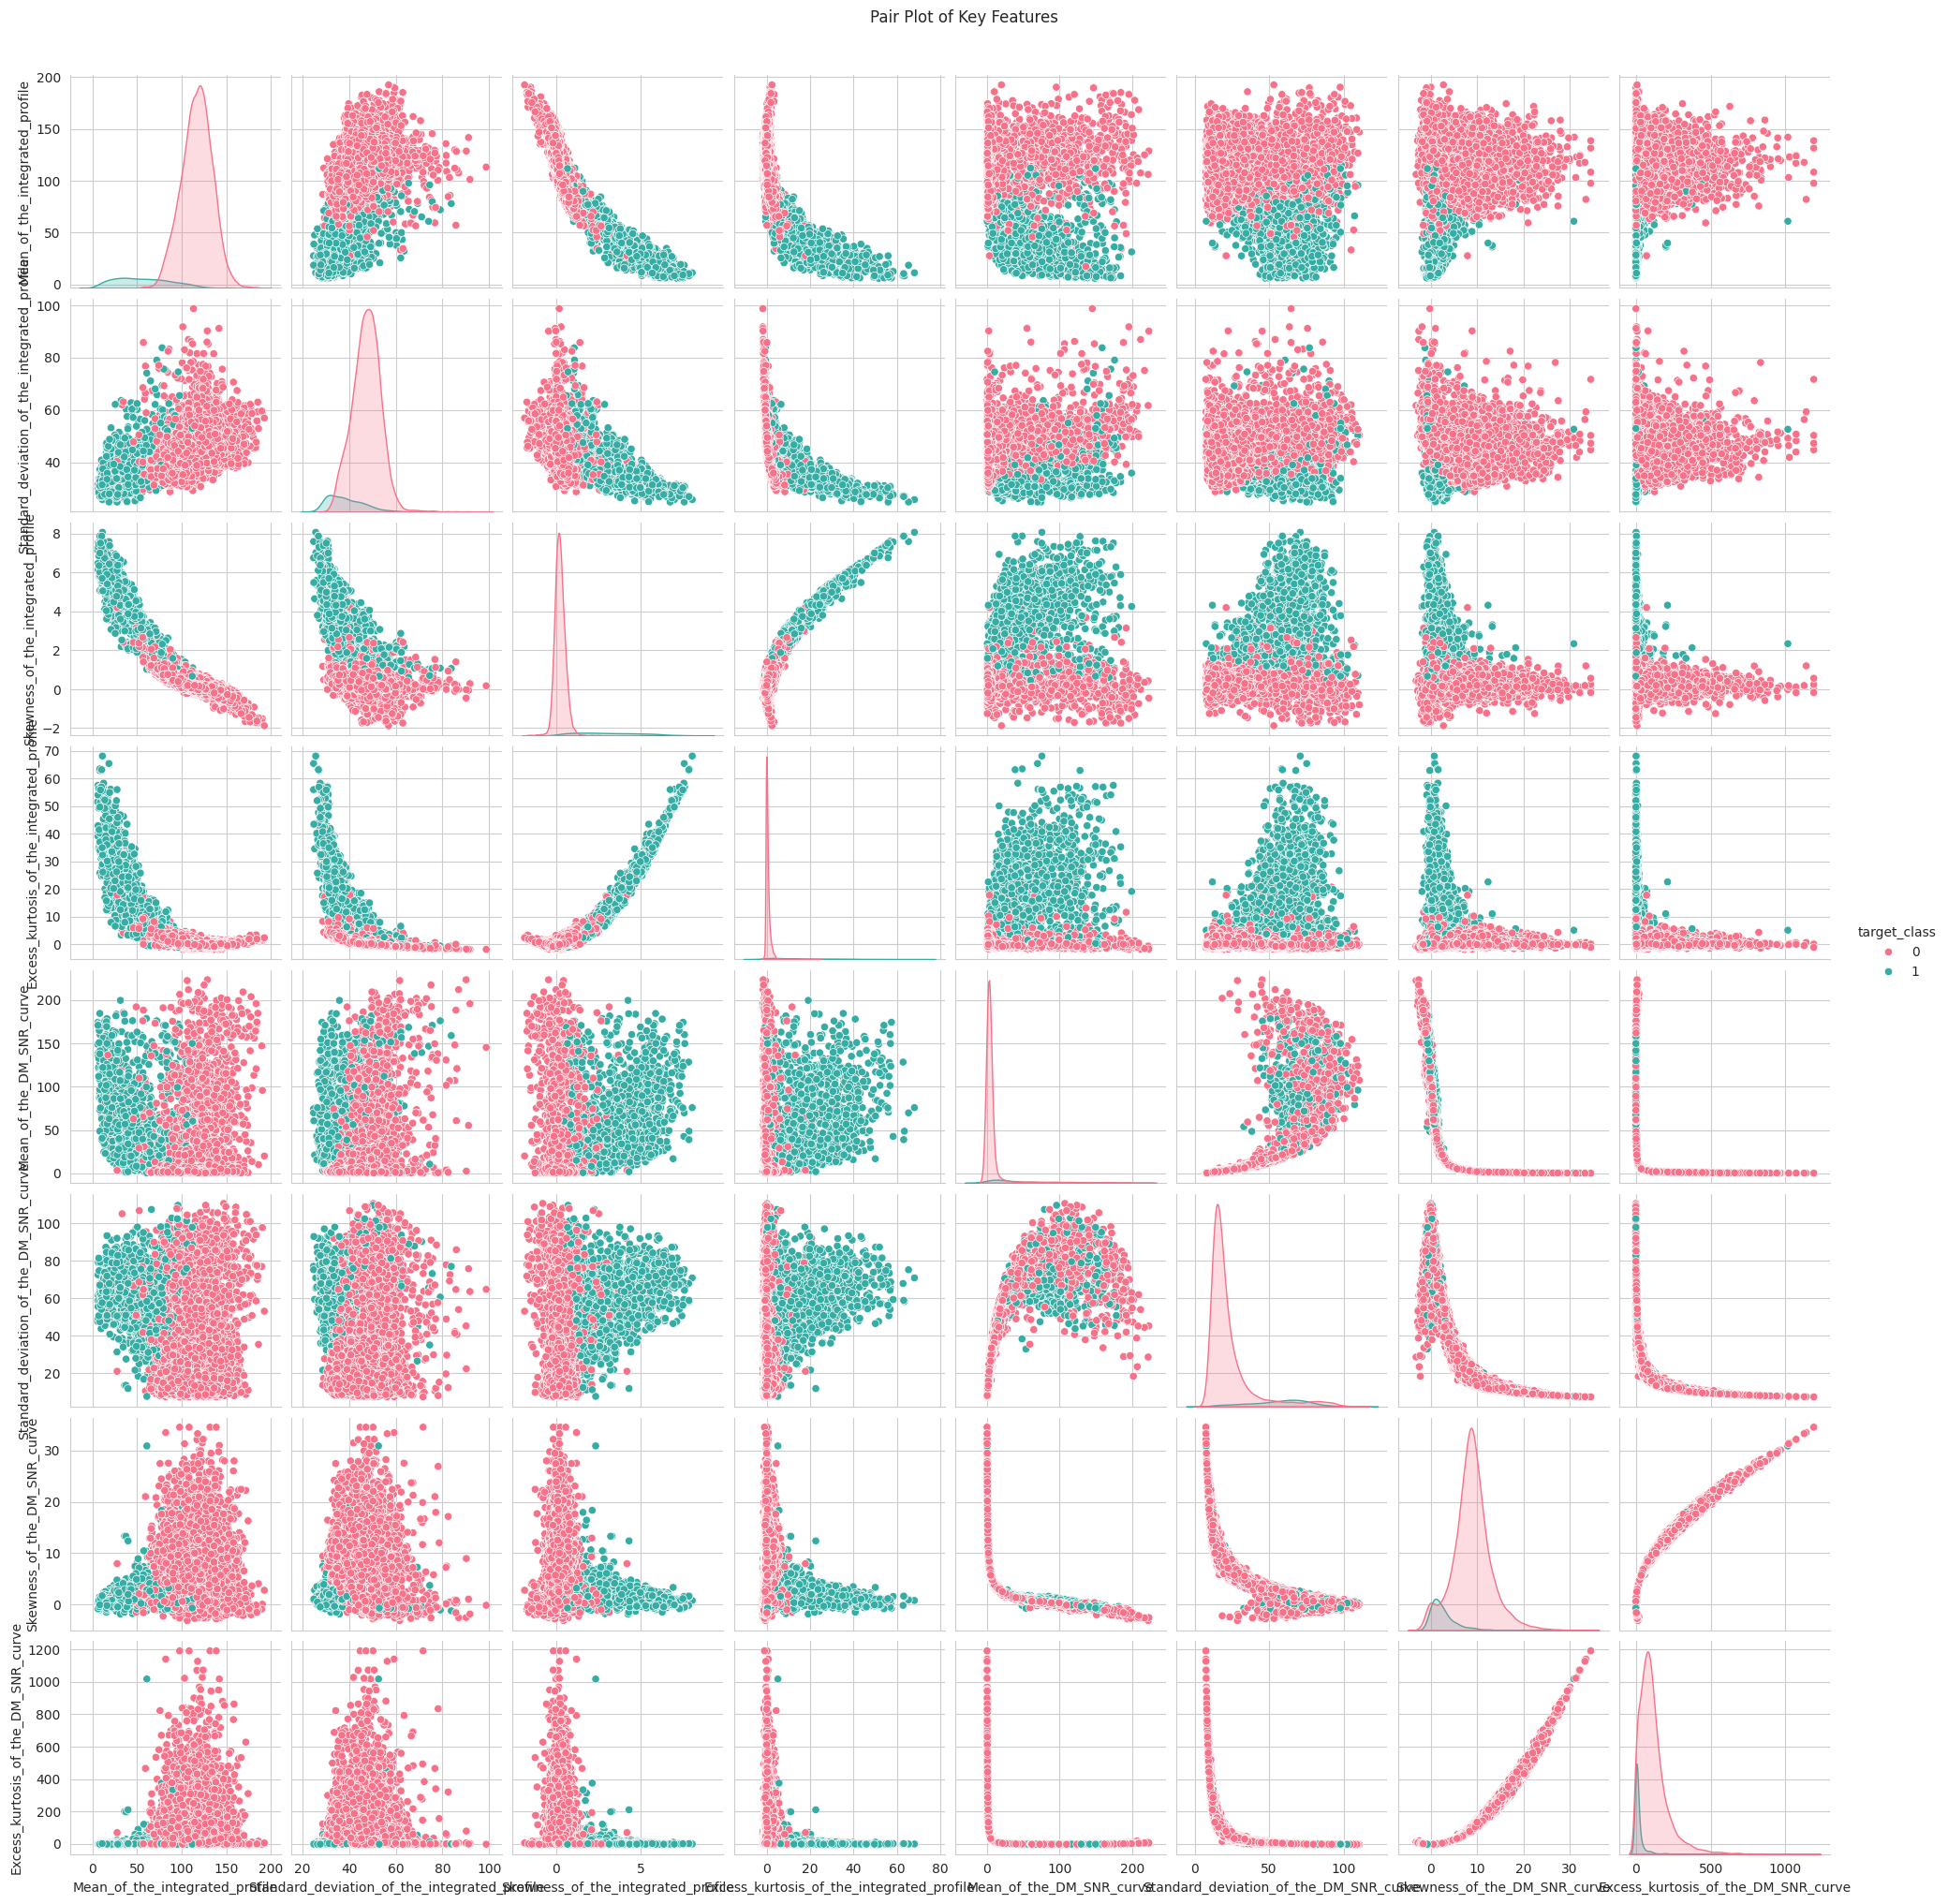

In [ ]:
# 2.4 Pair Plot
cols_to_plot = df.columns

sns.pairplot(df[cols_to_plot], hue='target_class', palette='husl', diag_kind='kde')
plt.suptitle('Pair Plot of Key Features', y=1.02)
plt.show()

3. Preprocessing and SMOTE
Since the dataset is highly imbalanced (approx 91% vs 9%), we will use SMOTE (Synthetic Minority Over-sampling Technique).

Strategy:

1) Split data into Train and Test sets.

2) Scale features (StandardScaler) - Essential for SVM, KNN, and MLP.

3) Apply SMOTE only to the Training set. (Applying to test set causes data leakage).

Original Training Class Distribution: 
target_class
0    12194
1     1229
Name: count, dtype: int64

SMOTE Training Class Distribution: 
target_class
0    12194
1    12194
Name: count, dtype: int64


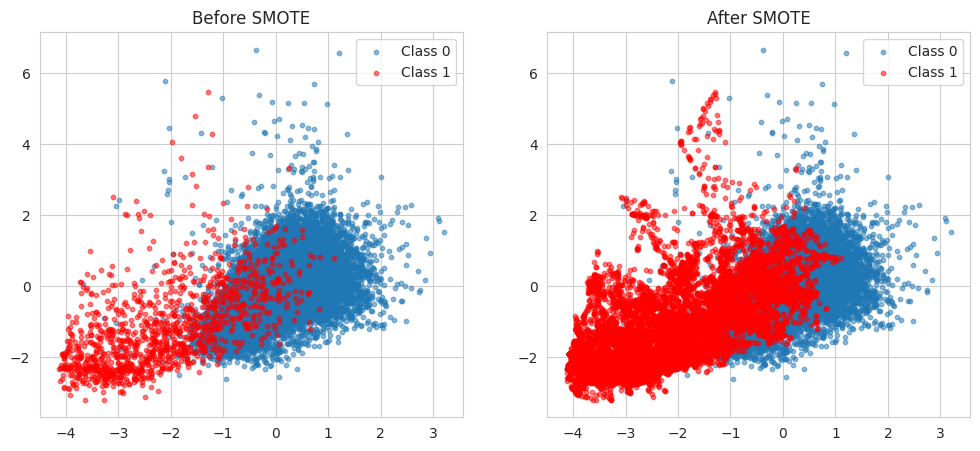

In [ ]:
# 1. Feature Separation
X = df.drop('target_class', axis=1)
y = df['target_class']

# 2. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. SMOTE Application
print(f"Original Training Class Distribution: \n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nSMOTE Training Class Distribution: \n{y_train_smote.value_counts()}")

# Visualize SMOTE effect (using first two features for 2D projection)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train_scaled[y_train==0][:,0], X_train_scaled[y_train==0][:,1], label='Class 0', alpha=0.5, s=10)
plt.scatter(X_train_scaled[y_train==1][:,0], X_train_scaled[y_train==1][:,1], label='Class 1', alpha=0.5, s=10, c='red')
plt.title("Before SMOTE")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_train_smote[y_train_smote==0][:,0], X_train_smote[y_train_smote==0][:,1], label='Class 0', alpha=0.5, s=10)
plt.scatter(X_train_smote[y_train_smote==1][:,0], X_train_smote[y_train_smote==1][:,1], label='Class 1', alpha=0.5, s=10, c='red')
plt.title("After SMOTE")
plt.legend()
plt.show()

4. Model Training & Comparison
We will train 7 models on two variations of data:

1) Normal Data: Scaled, Imbalanced.

2) SMOTE Data: Scaled, Balanced via oversampling.

Models: Logistic Regression, Random Forest, Naive Bayes, KNN, Decision Tree, MLP, SVM.

In [ ]:
# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=1000),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000),
    "SVM": SVC(probability=True) # probability=True needed for AUC
}

# Function to train and evaluate
def evaluate_models(models_dict, X_tr, y_tr, X_te, y_te, dataset_name):
    results = []

    for name, model in models_dict.items():
        # Train
        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_te)

        # Metrics
        acc = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred)
        rec = recall_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred)
        roc = roc_auc_score(y_te, y_prob)

        results.append({
            "Model": name,
            "Dataset": dataset_name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "AUC": roc,
            "Model_Obj": model # Saving model object for later
        })

    return pd.DataFrame(results)

# 1. Evaluate on Normal (Imbalanced) Data
results_normal = evaluate_models(models, X_train_scaled, y_train, X_test_scaled, y_test, "Normal")

# 2. Evaluate on SMOTE Data
results_smote = evaluate_models(models, X_train_smote, y_train_smote, X_test_scaled, y_test, "SMOTE")

# Combine Results
all_results = pd.concat([results_normal, results_smote], ignore_index=True)

print("Model Performance Sorted by F1 Score:")
display_cols = ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"]
all_results_display = all_results[display_cols]
display(all_results_display)

Model Performance Sorted by F1 Score:


,Model,Dataset,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,Normal,0.979441,0.944134,0.824390,0.880208,0.974001
1,Random Forest,Normal,0.980559,0.921671,0.860976,0.890290,0.970546
2,Naive Bayes,Normal,0.942570,0.638336,0.860976,0.733126,0.952637
3,KNN,Normal,0.979441,0.932065,0.836585,0.881748,0.952798
4,Decision Tree,Normal,0.966927,0.822660,0.814634,0.818627,0.898461
5,MLP (Neural Net),Normal,0.979441,0.918421,0.851220,0.883544,0.977263
6,SVM,Normal,0.980112,0.947075,0.829268,0.884265,0.957574
7,Logistic Regression,SMOTE,0.969385,0.789809,0.907317,0.844495,0.975116
8,Random Forest,SMOTE,0.976089,0.854801,0.890244,0.872162,0.971739
9,Naive Bayes,SMOTE,0.936983,0.609215,0.870732,0.716867,0.951837


5. PCA Analysis & Feature Importance
We select the best performing model (often Random Forest or SVM) for feature analysis. We also visualize the dataset in lower dimensions using PCA.

In [ ]:
# 5.1 PCA Projection (1D, 2D, 3D)

# Fit PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_test_scaled) # Visualizing test set

# Explained Variance
print(f"Explained Variance Ratio by 3 components: {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_):.2f}")

Explained Variance Ratio by 3 components: [0.50373772 0.27722238 0.10322002]
Total Variance Explained: 0.88


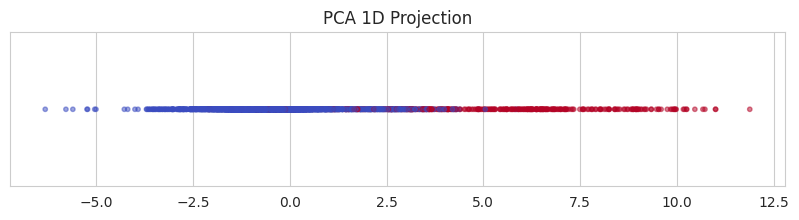

In [ ]:
# 1D Plot
plt.figure(figsize=(10, 2))
plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]), c=y_test, cmap='coolwarm', alpha=0.5, s=10)
plt.title('PCA 1D Projection')
plt.yticks([])
plt.show()

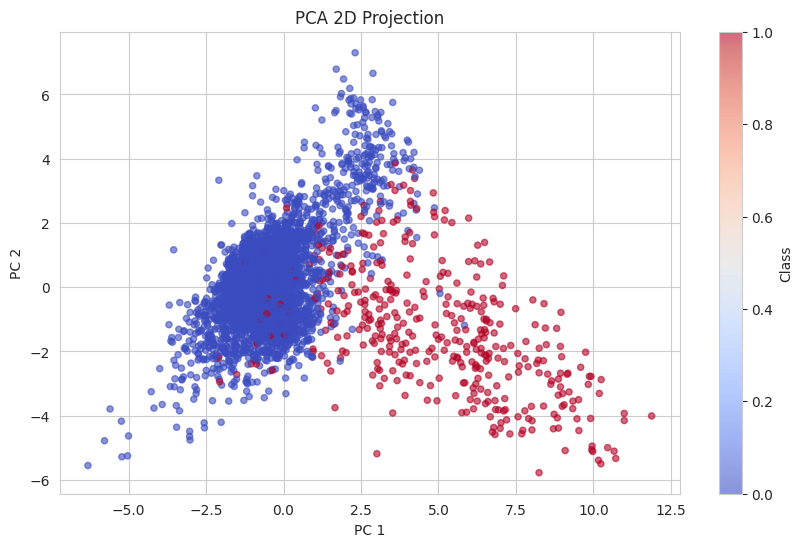

In [ ]:
# 2D Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_test, cmap='coolwarm', alpha=0.6, s=20)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('PCA 2D Projection')
plt.colorbar(scatter, label='Class')
plt.savefig('pca_2d.png')
plt.show()


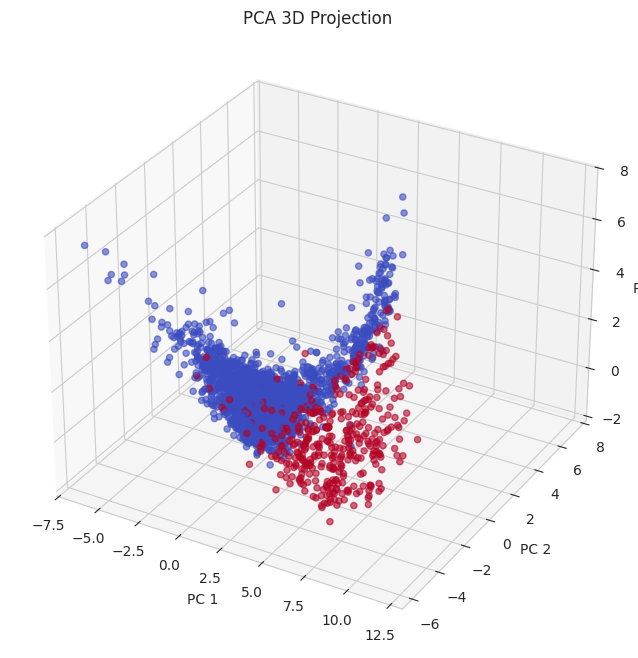

In [ ]:
# 3D Plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y_test, cmap='coolwarm', alpha=0.6)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('PCA 3D Projection')
plt.savefig('pca_3d.png')
plt.show()


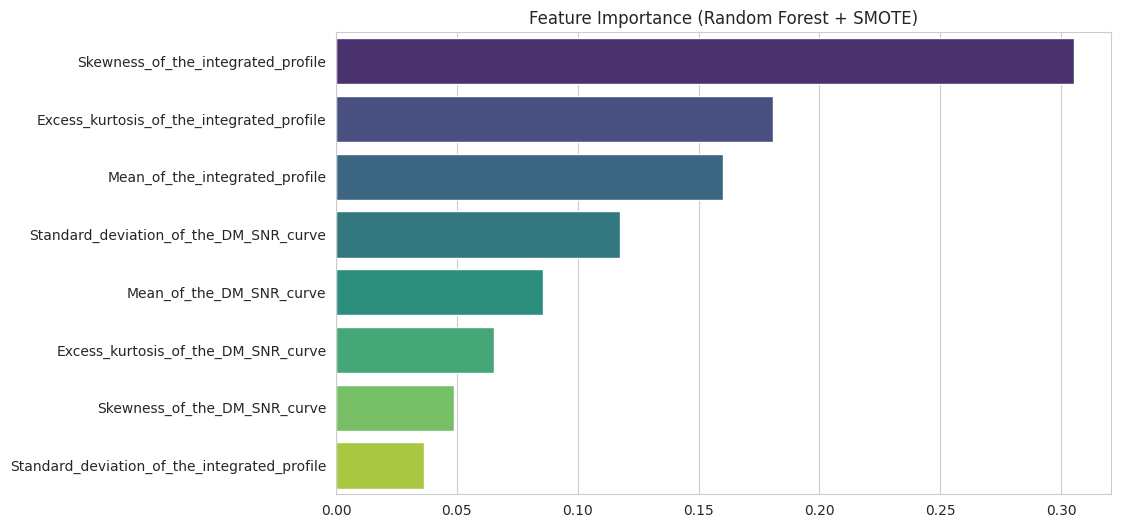

In [ ]:
# 5.2 Feature Importance (Using Random Forest from SMOTE training)
# Retrieving the RF model trained on SMOTE data
rf_model_smote = all_results[(all_results['Model'] == 'Random Forest') & (all_results['Dataset'] == 'SMOTE')]['Model_Obj'].values[0]

importances = rf_model_smote.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
plt.title('Feature Importance (Random Forest + SMOTE)')
plt.show()

6. Final Detailed Metrics
We pick the Best Performing Model (based on F1 Score) and show the Confusion Matrix and ROC Curve.

Best Model selected: Random Forest trained on Normal dataset


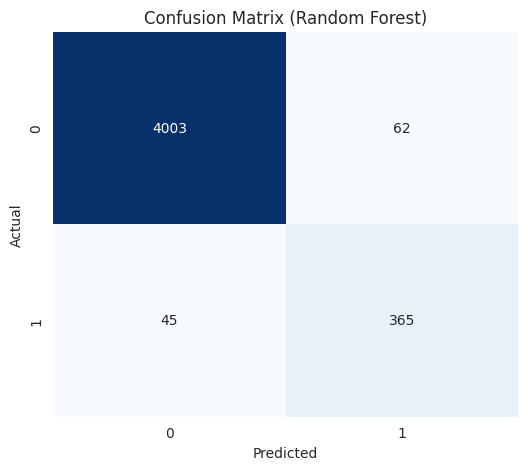

In [ ]:
# Identify best model
best_row = all_results.loc[all_results['F1 Score'].idxmax()]
best_model_name = best_row['Model']
best_dataset = best_row['Dataset']
best_model = best_row['Model_Obj']

print(f"Best Model selected: {best_model_name} trained on {best_dataset} dataset")

# Generate Predictions for detailed plotting
# Note: X_test_scaled is the same for both scenarios
y_pred_final = best_model.predict(X_test_scaled)
y_prob_final = best_model.predict_proba(X_test_scaled)[:, 1]

# 6.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix ({best_model_name})')
plt.savefig('confusion_matrix(Best Model).png')
plt.show()

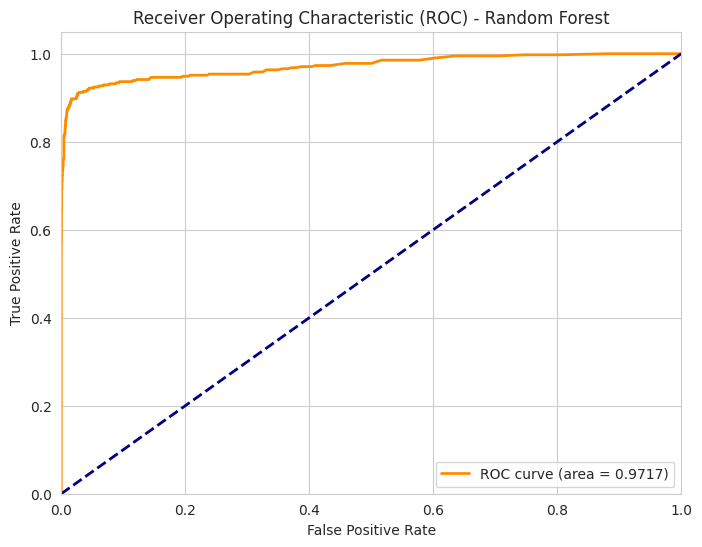

In [ ]:
# 6.2 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) - {best_model_name}')
plt.legend(loc="lower right")
plt.savefig('roc_curve(Best Model).png')
plt.show()

In [ ]:
# 6.3 Classification Report
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4065
           1       0.85      0.89      0.87       410

    accuracy                           0.98      4475
   macro avg       0.92      0.94      0.93      4475
weighted avg       0.98      0.98      0.98      4475

